# Aberrated Aperture Probe

Compare Gaussian Taylor beam propagation through a fixed concrete Krivanek phase-plate aberration set against a Fresnel propagator. The same aperture-probe coefficients are reused for the Gaussian, Hermite, and Fresnel comparisons so metric changes reflect the propagation model rather than new random aberrations.


## Setup

Configure JAX, import the required modules, and define a fixed aperture-probe aberration case.


In [31]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.2"

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.components import Detector, KrivanekLens
from temgym_core.constants import energy2wavelength
from temgym_core.gaussian import FreeSpacePropagator
from temgym_core.gaussian_corrections import (
    first_order_phase_residual_correction_factor,
    fit_phase_residual_polynomial_on_beam,
)
from temgym_core.source import circular_input_wave
from temgym_core.utils import AngularSpectrumPropagator, FresnelPropagator, zero_phase

# Use inline backend to avoid widget backend errors in environments without ipympl.
%matplotlib inline

jax.config.update("jax_enable_x64", True)
print("JAX backend:", jax.devices()[0].platform)

aperture_probe_coeff_samples = np.array(
    [
        -0.43461115653513716,
        -0.5958978706617057,
        -0.629488237418423,
        -0.6697193503441361,
        -0.857623969125477,
        -0.2804666724518379,
        0.6542298171451466,
        0.6975807590904051,
        0.6530028984830278,
    ],
    dtype=float,
)
print("Fixed aperture-probe coefficient samples:", aperture_probe_coeff_samples)


JAX backend: cpu
Fixed aperture-probe coefficient samples: [-0.43461116 -0.59589787 -0.62948824 -0.66971935 -0.85762397 -0.28046667
  0.65422982  0.69758076  0.6530029 ]


## Simulation Parameters

Define the microscope geometry, sampling grids, and helpers shared across the beam and Fresnel models.


In [32]:
from temgym_core.evaluate import evaluate_gaussians_jax_scan

voltage = 300_000  # V
wavelength = energy2wavelength(voltage)
k0 = 2 * jnp.pi / wavelength

aperture_radius = 0.15e-6  # m
window_width = 2e-6  # m
Nx = Ny = 256
pixel_size = window_width / Nx
focal_length = 5e-3  # m

input_grid = Detector(
    z=0.0,
    pixel_size=(pixel_size, pixel_size),
    shape=(Ny, Nx),
)
output_grid = Detector(
    z=focal_length * 2,
    pixel_size=(pixel_size, pixel_size),
    shape=(Ny, Nx),
)

idx_x = Nx // 2
idx_y = Ny // 2
x_coords, y_coords = output_grid.coords_1d


def center_zero_phase(field):
    """Anchor the global phase for easier visual comparison."""
    return zero_phase(field, idx_x, idx_y)


def field_from_rays(rays, grid):
    # Use CPU-based evaluation instead of GPU kernel
    field = evaluate_gaussians_jax_scan(rays, grid, batch_size=128)
    return field


## Fixed Aperture-Probe Aberration Coefficients

Use the fixed aperture-probe aberration samples and assemble the corresponding lens model.


In [33]:
r0, r1, r2, r3, r4, r5, r6, r7, r8 = aperture_probe_coeff_samples.tolist()

coeffs = KrivanekCoeffs(
    C30=1 * r0,
    C21=35 * r1,
    phi21=jnp.pi * r2,
    C23=15 * r3,
    phi23=jnp.pi * r4,
    C32=20 * r5,
    phi32=jnp.pi * r6,
    C43=20 * r7,
    phi43=jnp.pi * r0,
    C45=1 * r8,
)
print(coeffs)

phase_plate = KrivanekLens(focal_length=focal_length, z=focal_length, coeffs=coeffs)
phase_mask = jax.vmap(phase_plate.phase_shift)(output_grid.coords).reshape(output_grid.shape)

w0 = 8e-9  # beam waist (m)
rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=aperture_radius,
    waist=w0,
    sampling="fibonacci",
)
rays_in = rays_in.to_vector()


KrivanekCoeffs(C10=0.0, C12=0.0, phi12=0.0, C21=-20.8564254731597, phi21=-1.9775956221949051, C23=-10.045790255162041, phi23=-2.6943051609471182, C30=-0.43461115653513716, C32=-5.6093334490367575, phi32=2.055323587302586, C34=0.0, phi34=0.0, C41=0.0, phi41=0.0, C43=13.951615181808101, phi43=-1.3653712165389504, C45=0.6530028984830278, phi45=0.0, C50=0.0, C52=0.0, phi52=0.0, C54=0.0, phi54=0.0, C56=0.0, phi56=0.0)


## Propagate Beams

Propagate the Gaussian rays with the Taylor component update and compute matching Fresnel-field snapshots at each plane.


In [34]:
rays_after_input = rays_in
gaussian_field_at_input = field_from_rays(rays_after_input, input_grid)

rays_at_lens = FreeSpacePropagator()(rays_in, focal_length)
rays_after_lens = phase_plate(rays_at_lens)
gaussian_field_after_lens = field_from_rays(rays_after_lens, input_grid)

rays_after_free_space = FreeSpacePropagator()(rays_after_lens, focal_length)
gaussian_field_at_back_focal_plane = field_from_rays(rays_after_free_space, output_grid)

fresnel_field_at_input = zero_phase(gaussian_field_at_input, idx_x, idx_y)
fresnel_field_before_lens = FresnelPropagator(fresnel_field_at_input, window_width, wavelength, focal_length)
fresnel_field_after_lens = fresnel_field_before_lens * jnp.exp(1j * k0 * phase_mask)
fresnel_field_at_back_focal_plane = FresnelPropagator(fresnel_field_after_lens, window_width, wavelength, focal_length)

angular_field_at_input = zero_phase(gaussian_field_at_input, idx_x, idx_y)
angular_field_before_lens = AngularSpectrumPropagator(angular_field_at_input, window_width, wavelength, focal_length)
angular_field_after_lens = angular_field_before_lens * jnp.exp(1j * k0 * phase_mask)
angular_field_at_back_focal_plane = AngularSpectrumPropagator(angular_field_after_lens, window_width, wavelength, focal_length)


## Visualise Fields

Compare amplitudes and phases for the Gaussian and Fresnel solutions at the input, lens, and output planes.


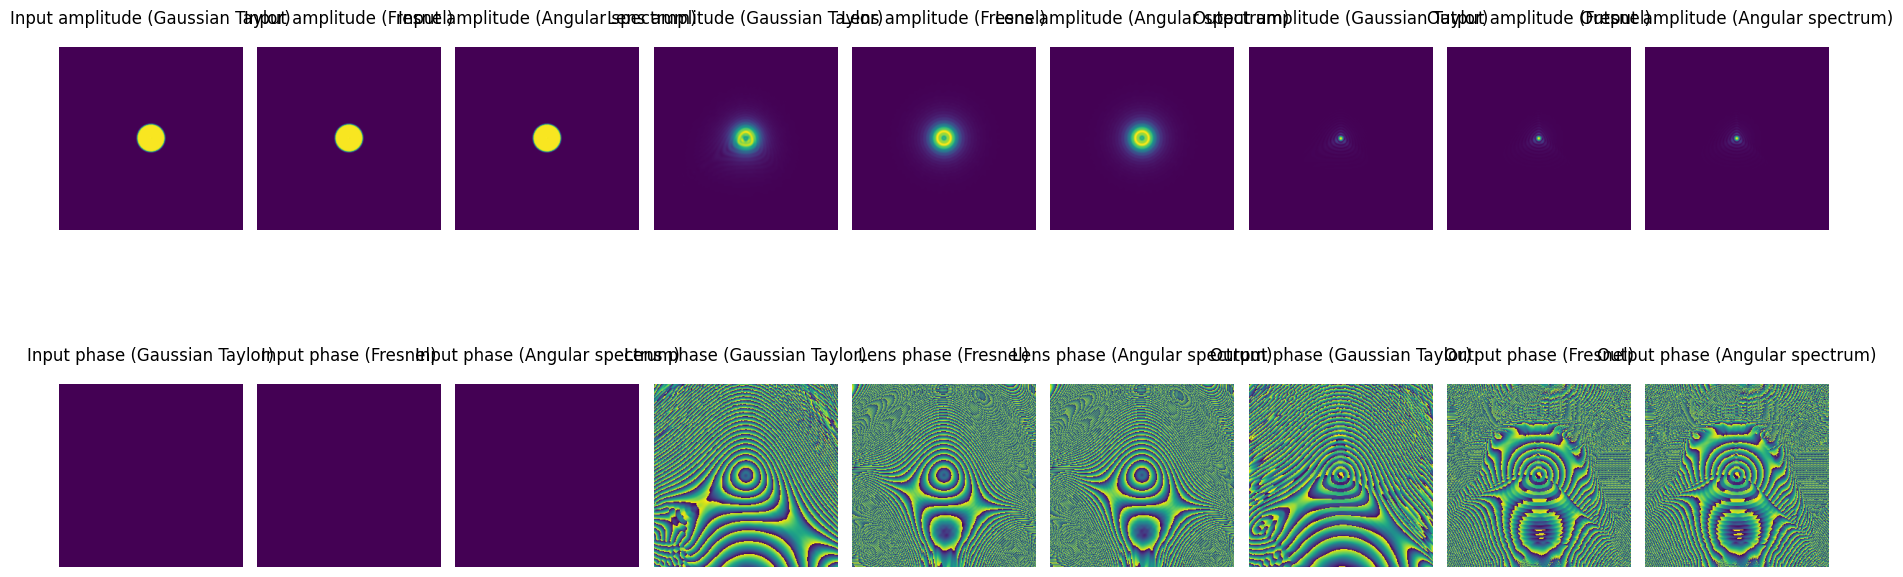

In [35]:
def show_field(ax, data, extent, title, cmap=None):
    im = ax.imshow(data, extent=extent, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")
    return im

fig, axes = plt.subplots(2, 9, figsize=(18, 8))
field_summaries = [
    ("Input", gaussian_field_at_input, fresnel_field_at_input, angular_field_at_input, input_grid.extent),
    ("Lens", gaussian_field_after_lens, fresnel_field_after_lens, angular_field_after_lens, input_grid.extent),
    ("Output", gaussian_field_at_back_focal_plane, fresnel_field_at_back_focal_plane, angular_field_at_back_focal_plane, output_grid.extent),
]
method_labels = ["Gaussian Taylor", "Fresnel", "Angular spectrum"]

for col, (label, gaussian_field, fresnel_field, angular_field, extent) in enumerate(field_summaries):
    for method_idx, (method_label, field) in enumerate(zip(method_labels, (gaussian_field, fresnel_field, angular_field))):
        ax_col = 3 * col + method_idx
        show_field(axes[0, ax_col], np.abs(field), extent, f"{label} amplitude ({method_label})")
        show_field(axes[1, ax_col], np.angle(field), extent, f"{label} phase ({method_label})")

plt.tight_layout()
plt.show()


## Quantitative Output Agreement

Use the generated aberrated aperture probe image from the Taylor Gaussian propagation path and compare it directly with the Fresnel reference at the back focal plane.


Aberration case: fixed aperture-probe coefficient samples
Gaussian propagation method: Taylor quadratic component action
Input Gaussian beams: 4418
Gaussian Taylor vs Fresnel aligned field error: 0.1486
Gaussian Taylor vs Fresnel normalized intensity error: 0.02314
Gaussian Taylor vs Fresnel normalized intensity RMSE: 0.0002864
Angular spectrum vs Fresnel aligned field error: 1.274e-06
Angular spectrum vs Fresnel normalized intensity error: 1.041e-07
Angular spectrum vs Fresnel normalized intensity RMSE: 1.289e-09
Gaussian/Fresnel alignment scale: 0.9867+0.001344j


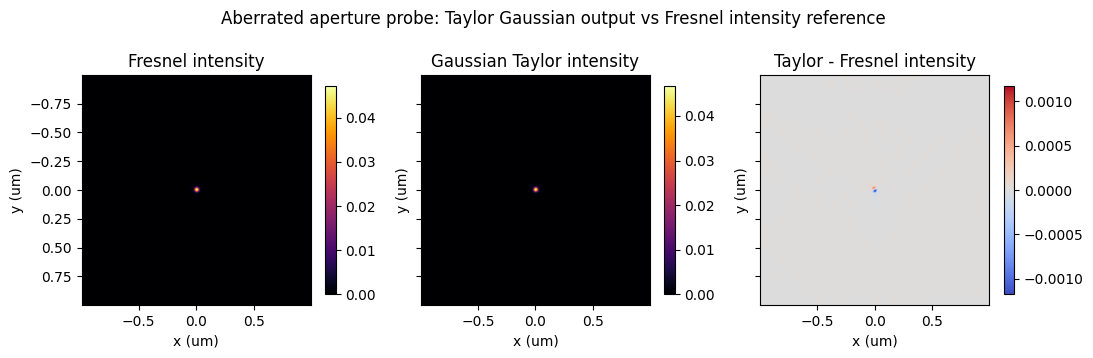

In [36]:
def aligned_field_error(test, ref):
    alpha = jnp.vdot(test, ref) / jnp.vdot(test, test)
    return float(jnp.linalg.norm(alpha * test - ref) / jnp.linalg.norm(ref)), alpha


def normalized_intensity_metrics(test, ref):
    test_i = jnp.abs(test) ** 2
    ref_i = jnp.abs(ref) ** 2
    test_i = test_i / jnp.sum(test_i)
    ref_i = ref_i / jnp.sum(ref_i)
    relative_l2 = jnp.linalg.norm(test_i - ref_i) / jnp.linalg.norm(ref_i)
    normalized_rmse = jnp.sqrt(jnp.mean((test_i - ref_i) ** 2)) / jnp.max(ref_i)
    return float(relative_l2), float(normalized_rmse)


def block_until_ready(value):
    def block_leaf(x):
        return x.block_until_ready() if hasattr(x, "block_until_ready") else x

    return jax.tree_util.tree_map(block_leaf, value)


gaussian_output = center_zero_phase(gaussian_field_at_back_focal_plane)
fresnel_output = center_zero_phase(fresnel_field_at_back_focal_plane)
angular_output = center_zero_phase(angular_field_at_back_focal_plane)
gaussian_output, fresnel_output, angular_output = block_until_ready(
    (gaussian_output, fresnel_output, angular_output)
)

gaussian_field_error, gaussian_to_fresnel_scale = aligned_field_error(
    gaussian_output,
    fresnel_output,
)
angular_field_error, _ = aligned_field_error(angular_output, fresnel_output)
gaussian_intensity_error, gaussian_intensity_rmse = normalized_intensity_metrics(gaussian_output, fresnel_output)
angular_intensity_error, angular_intensity_rmse = normalized_intensity_metrics(angular_output, fresnel_output)

print("Aberration case: fixed aperture-probe coefficient samples")
print("Gaussian propagation method: Taylor quadratic component action")
print(f"Input Gaussian beams: {np.asarray(rays_in.x).size}")
print(f"Gaussian Taylor vs Fresnel aligned field error: {gaussian_field_error:.4g}")
print(f"Gaussian Taylor vs Fresnel normalized intensity error: {gaussian_intensity_error:.4g}")
print(f"Gaussian Taylor vs Fresnel normalized intensity RMSE: {gaussian_intensity_rmse:.4g}")
print(f"Angular spectrum vs Fresnel aligned field error: {angular_field_error:.4g}")
print(f"Angular spectrum vs Fresnel normalized intensity error: {angular_intensity_error:.4g}")
print(f"Angular spectrum vs Fresnel normalized intensity RMSE: {angular_intensity_rmse:.4g}")
print(f"Gaussian/Fresnel alignment scale: {complex(np.asarray(gaussian_to_fresnel_scale)):.4g}")

gaussian_aligned = gaussian_to_fresnel_scale * gaussian_output
fresnel_np = np.asarray(fresnel_output)
gaussian_np = np.asarray(gaussian_aligned)
fresnel_intensity = np.abs(fresnel_np) ** 2
gaussian_intensity = np.abs(gaussian_np) ** 2
fresnel_intensity_norm = fresnel_intensity / np.sum(fresnel_intensity)
gaussian_intensity_norm = gaussian_intensity / np.sum(gaussian_intensity)
taylor_difference = gaussian_intensity_norm - fresnel_intensity_norm
difference_limit = np.max(np.abs(taylor_difference))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
images = [
    (fresnel_intensity_norm, "Fresnel intensity", "inferno", None),
    (gaussian_intensity_norm, "Gaussian Taylor intensity", "inferno", None),
    (taylor_difference, "Taylor - Fresnel intensity", "coolwarm", difference_limit),
]
extent_um = tuple(float(v) * 1e6 for v in output_grid.extent)
for ax, (data, title, cmap, limit) in zip(axes, images):
    kwargs = {}
    if limit is not None and limit > 0:
        kwargs.update(vmin=-limit, vmax=limit)
    im = ax.imshow(data, extent=extent_um, origin="lower", cmap=cmap, **kwargs)
    ax.set_title(title)
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle("Aberrated aperture probe: Taylor Gaussian output vs Fresnel intensity reference")
fig.tight_layout()
plt.show()


## Hermite First-Order Diagnostic

Run a reduced aperture-probe calculation with the same fixed aberration coefficients and compare Taylor propagation with the first-order Hermite residual correction. The correction is evaluated as a diagnostic loop, not as the production propagation path, because this concrete coherent-intensity case can expose settings where Hermite loses to Taylor.


In [37]:
hermite_diagnostic_config = {
    "label": "deg3-4 nominal",
    "grid_size": 36,
    "waist": 80e-9,
    "overlap_factor": 2.0,
    "edge_fraction": 1.0,
    "fit_min_degree": 3,
    "fit_max_degree": 4,
    "fit_support_radius": 1.0,
    "fit_samples_per_axis": 7,
    "clip_limit": 0.5,
    "damping": 1.0,
}


def square_detector(z, grid_size):
    pixel_size = window_width / grid_size
    return Detector(
        z=z,
        pixel_size=(pixel_size, pixel_size),
        shape=(grid_size, grid_size),
    )


def zero_phase_for_grid(grid_size):
    idx = grid_size // 2
    return lambda field: zero_phase(field, idx, idx)


def prune_edge_beams(rays, edge_fraction):
    vector = rays.to_vector()
    if edge_fraction is None or edge_fraction >= 1.0:
        return vector

    radius = jnp.sqrt(vector.x**2 + vector.y**2)
    keep = np.asarray(radius <= aperture_radius * edge_fraction)
    if not np.any(keep):
        raise ValueError(f"edge_fraction={edge_fraction} removed every beam")
    return vector[keep].to_vector()


def single_beam_field_at_coords(ray, coords):
    delta = coords - ray.r_xy
    linear = delta @ ray.d_xy
    quadratic = jnp.sum((delta @ ray.Q_inv) * delta, axis=-1)
    phase = ray.pathlength + linear + 0.5 * quadratic
    return ray.amplitude * jnp.exp(1j * ray.k * phase)


def clipped_complex_factor(factor, limit):
    magnitude = jnp.abs(factor)
    return jnp.where(magnitude > limit, factor * (limit / (magnitude + 1e-300)), factor)


def hermite_corrected_output_field(
    rays_at_lens,
    taylor_rays_at_lens,
    grid,
    *,
    fit_min_degree,
    fit_max_degree,
    fit_support_radius,
    fit_samples_per_axis,
    damping,
    clip_limit=None,
):
    coords = grid.coords
    vector = rays_at_lens.to_vector()
    taylor_vector = taylor_rays_at_lens.to_vector()
    total = jnp.zeros((coords.shape[0],), dtype=jnp.complex128)
    raw_max_factor = 0.0
    applied_max_factor = 0.0

    for i in range(int(np.asarray(vector.x).size)):
        ray = vector[i]
        taylor_ray = taylor_vector[i]
        output_ray = FreeSpacePropagator()(taylor_ray, focal_length)
        base_field = single_beam_field_at_coords(output_ray, coords)

        taylor_coefficients = (
            taylor_ray.pathlength - ray.pathlength,
            taylor_ray.d_xy - ray.d_xy,
            taylor_ray.Q_inv - ray.Q_inv,
        )
        residual_fit = fit_phase_residual_polynomial_on_beam(
            phase_plate.phase_shift,
            ray,
            taylor_coefficients=taylor_coefficients,
            min_degree=fit_min_degree,
            max_degree=fit_max_degree,
            fit_support_radius=fit_support_radius,
            fit_samples_per_axis=fit_samples_per_axis,
        )
        factor = first_order_phase_residual_correction_factor(
            taylor_ray,
            coords,
            focal_length,
            residual_fit,
        )
        raw_max_factor = max(raw_max_factor, float(jnp.max(jnp.abs(factor))))
        factor = damping * factor
        if clip_limit is not None:
            factor = clipped_complex_factor(factor, clip_limit)
        applied_max_factor = max(applied_max_factor, float(jnp.max(jnp.abs(factor))))
        total = total + base_field * (1.0 + factor)

    return total.reshape(grid.shape), raw_max_factor, applied_max_factor


def make_reduced_aperture_case(config):
    grid_size = int(config["grid_size"])
    zero_phase_fn = zero_phase_for_grid(grid_size)
    input_grid = square_detector(0.0, grid_size)
    lens_grid = square_detector(focal_length, grid_size)
    output_grid = square_detector(2 * focal_length, grid_size)

    rays_in = circular_input_wave(
        voltage=voltage,
        aperture_radius=aperture_radius,
        waist=float(config["waist"]),
        overlap_factor=float(config.get("overlap_factor", 2.0)),
        sampling="fibonacci",
    ).to_vector()
    rays_in = prune_edge_beams(rays_in, float(config.get("edge_fraction", 1.0)))

    rays_at_lens = FreeSpacePropagator()(rays_in, focal_length)
    taylor_rays_at_lens = phase_plate(rays_at_lens)
    taylor_rays_out = FreeSpacePropagator()(taylor_rays_at_lens, focal_length)

    input_field = evaluate_gaussians_jax_scan(
        rays_in,
        input_grid,
        batch_size=256,
    )
    phase_mask = jax.vmap(phase_plate.phase_shift)(lens_grid.coords).reshape(lens_grid.shape)
    fresnel_field = FresnelPropagator(
        FresnelPropagator(
            zero_phase_fn(input_field),
            window_width,
            wavelength,
            focal_length,
        )
        * jnp.exp(1j * k0 * phase_mask),
        window_width,
        wavelength,
        focal_length,
    )
    taylor_field = evaluate_gaussians_jax_scan(
        taylor_rays_out,
        output_grid,
        batch_size=256,
    )
    return {
        "grid_size": grid_size,
        "input_grid": input_grid,
        "output_grid": output_grid,
        "zero_phase": zero_phase_fn,
        "rays_in": rays_in,
        "rays_at_lens": rays_at_lens,
        "taylor_rays_at_lens": taylor_rays_at_lens,
        "fresnel_field": fresnel_field,
        "taylor_field": taylor_field,
    }


def run_hermite_diagnostic(config):
    case = make_reduced_aperture_case(config)
    hermite_field, raw_max_factor, applied_max_factor = hermite_corrected_output_field(
        case["rays_at_lens"],
        case["taylor_rays_at_lens"],
        case["output_grid"],
        fit_min_degree=int(config["fit_min_degree"]),
        fit_max_degree=int(config["fit_max_degree"]),
        fit_support_radius=float(config["fit_support_radius"]),
        fit_samples_per_axis=int(config["fit_samples_per_axis"]),
        damping=float(config.get("damping", 1.0)),
        clip_limit=config.get("clip_limit"),
    )
    fresnel_field, taylor_field, hermite_field = block_until_ready(
        (case["fresnel_field"], case["taylor_field"], hermite_field)
    )

    zero_phase_fn = case["zero_phase"]
    taylor_field_error, taylor_scale = aligned_field_error(
        zero_phase_fn(taylor_field),
        zero_phase_fn(fresnel_field),
    )
    hermite_field_error, hermite_scale = aligned_field_error(
        zero_phase_fn(hermite_field),
        zero_phase_fn(fresnel_field),
    )
    taylor_intensity_error, taylor_intensity_rmse = normalized_intensity_metrics(
        taylor_field,
        fresnel_field,
    )
    hermite_intensity_error, hermite_intensity_rmse = normalized_intensity_metrics(
        hermite_field,
        fresnel_field,
    )

    result = dict(config)
    result.update(
        {
            "grid_size": case["grid_size"],
            "beam_count": int(np.asarray(case["rays_in"].x).size),
            "output_grid": case["output_grid"],
            "zero_phase": zero_phase_fn,
            "fresnel_field": fresnel_field,
            "taylor_field": taylor_field,
            "hermite_field": hermite_field,
            "taylor_scale": taylor_scale,
            "hermite_scale": hermite_scale,
            "raw_max_factor": raw_max_factor,
            "applied_max_factor": applied_max_factor,
            "taylor_field_error": taylor_field_error,
            "hermite_field_error": hermite_field_error,
            "taylor_intensity_error": taylor_intensity_error,
            "hermite_intensity_error": hermite_intensity_error,
            "taylor_intensity_rmse": taylor_intensity_rmse,
            "hermite_intensity_rmse": hermite_intensity_rmse,
            "rmse_delta": hermite_intensity_rmse - taylor_intensity_rmse,
        }
    )
    return result


hermite_result = run_hermite_diagnostic(hermite_diagnostic_config)

hermite_Nx = hermite_Ny = hermite_result["grid_size"]
hermite_waist = hermite_result["waist"]
hermite_clip_limit = hermite_result["clip_limit"]
hermite_output_grid = hermite_result["output_grid"]
hermite_zero_phase = hermite_result["zero_phase"]
hermite_fresnel_field = hermite_result["fresnel_field"]
hermite_taylor_field = hermite_result["taylor_field"]
hermite_field = hermite_result["hermite_field"]
hermite_taylor_scale = hermite_result["taylor_scale"]
hermite_scale = hermite_result["hermite_scale"]
hermite_max_factor = hermite_result["raw_max_factor"]

print("Hermite diagnostic aberration case: fixed aperture-probe coefficient samples")
print(f"Hermite diagnostic grid: {hermite_Ny} x {hermite_Nx}")
print(f"Hermite diagnostic waist: {hermite_waist:.3g} m")
print(f"Hermite diagnostic overlap factor: {hermite_result['overlap_factor']}")
print(f"Hermite diagnostic edge fraction: {hermite_result['edge_fraction']}")
print(f"Hermite diagnostic input beams: {hermite_result['beam_count']}")
print(f"Hermite residual polynomial degree: {hermite_result['fit_min_degree']}-{hermite_result['fit_max_degree']}")
print(f"Hermite residual support radius: {hermite_result['fit_support_radius']}")
print(f"Hermite residual fit samples per axis: {hermite_result['fit_samples_per_axis']}")
print(f"Hermite correction damping: {hermite_result['damping']}")
print(f"Hermite correction clip limit: {hermite_clip_limit}")
print(f"Unclipped max |Hermite correction factor|: {hermite_result['raw_max_factor']:.4g}")
print(f"Applied max |Hermite correction factor|: {hermite_result['applied_max_factor']:.4g}")
print(f"Taylor vs Fresnel aligned field error: {hermite_result['taylor_field_error']:.4g}")
print(f"Hermite vs Fresnel aligned field error: {hermite_result['hermite_field_error']:.4g}")
print(f"Taylor vs Fresnel normalized intensity error: {hermite_result['taylor_intensity_error']:.4g}")
print(f"Hermite vs Fresnel normalized intensity error: {hermite_result['hermite_intensity_error']:.4g}")
print(f"Taylor vs Fresnel normalized intensity RMSE: {hermite_result['taylor_intensity_rmse']:.4g}")
print(f"Hermite vs Fresnel normalized intensity RMSE: {hermite_result['hermite_intensity_rmse']:.4g}")
print(f"Hermite - Taylor normalized intensity RMSE: {hermite_result['rmse_delta']:.4g}")


Hermite diagnostic aberration case: fixed aperture-probe coefficient samples
Hermite diagnostic grid: 36 x 36
Hermite diagnostic waist: 8e-08 m
Hermite diagnostic overlap factor: 2.0
Hermite diagnostic edge fraction: 1.0
Hermite diagnostic input beams: 45
Hermite residual polynomial degree: 3-4
Hermite residual support radius: 1.0
Hermite residual fit samples per axis: 7
Hermite correction damping: 1.0
Hermite correction clip limit: 0.5
Unclipped max |Hermite correction factor|: 9149
Applied max |Hermite correction factor|: 0.5
Taylor vs Fresnel aligned field error: 0.9495
Hermite vs Fresnel aligned field error: 0.9443
Taylor vs Fresnel normalized intensity error: 2.148
Hermite vs Fresnel normalized intensity error: 2.189
Taylor vs Fresnel normalized intensity RMSE: 0.1143
Hermite vs Fresnel normalized intensity RMSE: 0.1165
Hermite - Taylor normalized intensity RMSE: 0.002192


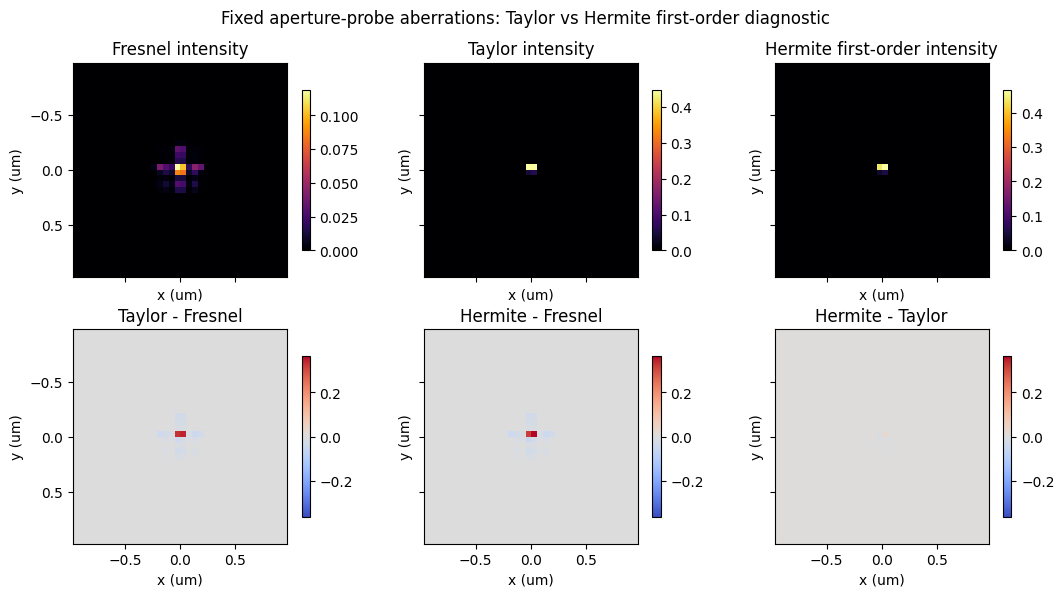

In [38]:
hermite_fresnel_np = np.asarray(hermite_fresnel_field)
hermite_taylor_np = np.asarray(hermite_taylor_scale * hermite_zero_phase(hermite_taylor_field))
hermite_np = np.asarray(hermite_scale * hermite_zero_phase(hermite_field))

hermite_fresnel_intensity = np.abs(hermite_fresnel_np) ** 2
hermite_taylor_intensity = np.abs(hermite_taylor_np) ** 2
hermite_corrected_intensity = np.abs(hermite_np) ** 2
hermite_fresnel_norm = hermite_fresnel_intensity / np.sum(hermite_fresnel_intensity)
hermite_taylor_norm = hermite_taylor_intensity / np.sum(hermite_taylor_intensity)
hermite_corrected_norm = hermite_corrected_intensity / np.sum(hermite_corrected_intensity)
hermite_taylor_difference = hermite_taylor_norm - hermite_fresnel_norm
hermite_difference = hermite_corrected_norm - hermite_fresnel_norm
hermite_difference_limit = max(
    np.max(np.abs(hermite_taylor_difference)),
    np.max(np.abs(hermite_difference)),
)

fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
images = [
    (hermite_fresnel_norm, "Fresnel intensity", "inferno", None),
    (hermite_taylor_norm, "Taylor intensity", "inferno", None),
    (hermite_corrected_norm, "Hermite first-order intensity", "inferno", None),
    (hermite_taylor_difference, "Taylor - Fresnel", "coolwarm", hermite_difference_limit),
    (hermite_difference, "Hermite - Fresnel", "coolwarm", hermite_difference_limit),
    (hermite_corrected_norm - hermite_taylor_norm, "Hermite - Taylor", "coolwarm", hermite_difference_limit),
]
hermite_extent_um = tuple(float(v) * 1e6 for v in hermite_output_grid.extent)
for ax, (data, title, cmap, limit) in zip(axes.ravel(), images):
    kwargs = {}
    if limit is not None and limit > 0:
        kwargs.update(vmin=-limit, vmax=limit)
    im = ax.imshow(data, extent=hermite_extent_um, origin="lower", cmap=cmap, **kwargs)
    ax.set_title(title)
    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    fig.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle("Fixed aperture-probe aberrations: Taylor vs Hermite first-order diagnostic")
fig.tight_layout()
plt.show()


## Hermite Accuracy Sweep

Sweep the concrete aperture-probe case over residual polynomial degree, fit support, sample density, clipping, damping, Gaussian waist/spacing, and edge-beam pruning. Each row builds its Fresnel reference from the same reduced Gaussian input bundle used by Taylor and Hermite, then ranks the settings by normalized intensity RMSE.


In [ ]:
hermite_sweep_configs = [
    dict(hermite_diagnostic_config),
    dict(hermite_diagnostic_config, label="degree 3-5", fit_max_degree=5, fit_samples_per_axis=9),
    dict(hermite_diagnostic_config, label="core support", fit_support_radius=0.7),
    dict(hermite_diagnostic_config, label="wide support", fit_support_radius=1.3),
    dict(hermite_diagnostic_config, label="tight clip", clip_limit=0.1),
    dict(hermite_diagnostic_config, label="damped 0.25", damping=0.25),
    dict(hermite_diagnostic_config, label="smaller waist", waist=60e-9),
    dict(hermite_diagnostic_config, label="larger waist", waist=100e-9),
    dict(hermite_diagnostic_config, label="denser spacing", overlap_factor=2.5),
    dict(hermite_diagnostic_config, label="edge pruned", edge_fraction=0.8),
]

hermite_sweep_results = []
for config in hermite_sweep_configs:
    if config == hermite_diagnostic_config:
        result = hermite_result
    else:
        result = run_hermite_diagnostic(config)
    hermite_sweep_results.append(result)

ranked_results = sorted(hermite_sweep_results, key=lambda row: row["hermite_intensity_rmse"])

print("Ranked by Hermite normalized intensity RMSE against the matching Fresnel reference")
header = (
    f"{'rank':>4}  {'label':<15} {'deg':<5} {'waist_nm':>8} {'overlap':>7} "
    f"{'edge':>5} {'support':>7} {'samples':>7} {'clip':>7} {'damp':>6} "
    f"{'beams':>6} {'Taylor':>10} {'Hermite':>10} {'delta':>10} {'winner':>8}"
)
print(header)
print("-" * len(header))
for rank, row in enumerate(ranked_results, start=1):
    degree = f"{row['fit_min_degree']}-{row['fit_max_degree']}"
    clip = "None" if row["clip_limit"] is None else f"{row['clip_limit']:.2g}"
    winner = "Hermite" if row["rmse_delta"] < 0 else "Taylor"
    print(
        f"{rank:>4}  {row['label']:<15} {degree:<5} "
        f"{row['waist'] * 1e9:>8.1f} {row['overlap_factor']:>7.2f} "
        f"{row['edge_fraction']:>5.2f} {row['fit_support_radius']:>7.2f} "
        f"{row['fit_samples_per_axis']:>7d} {clip:>7} {row['damping']:>6.2f} "
        f"{row['beam_count']:>6d} {row['taylor_intensity_rmse']:>10.4g} "
        f"{row['hermite_intensity_rmse']:>10.4g} {row['rmse_delta']:>10.4g} {winner:>8}"
    )

best_row = ranked_results[0]
baseline_row = hermite_sweep_results[0]
print()
print(f"Best Hermite setting: {best_row['label']} with RMSE {best_row['hermite_intensity_rmse']:.4g}")
print(f"Nominal Taylor baseline RMSE: {baseline_row['taylor_intensity_rmse']:.4g}")
print(f"Nominal Hermite RMSE: {baseline_row['hermite_intensity_rmse']:.4g}")
print(f"Nominal Hermite - Taylor RMSE: {baseline_row['rmse_delta']:.4g}")

ordered_labels = [row["label"] for row in ranked_results]
taylor_rmse = np.array([row["taylor_intensity_rmse"] for row in ranked_results])
hermite_rmse = np.array([row["hermite_intensity_rmse"] for row in ranked_results])
x = np.arange(len(ranked_results))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - 0.18, taylor_rmse, width=0.36, label="Taylor")
ax.bar(x + 0.18, hermite_rmse, width=0.36, label="Hermite first-order")
ax.set_xticks(x)
ax.set_xticklabels(ordered_labels, rotation=35, ha="right")
ax.set_ylabel("Normalized intensity RMSE")
ax.set_title("Fixed aperture-probe aberrations: Hermite sweep ranked against Fresnel")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


## Output Cross-Section

Inspect the amplitude profile along the central horizontal cut in the back focal plane.


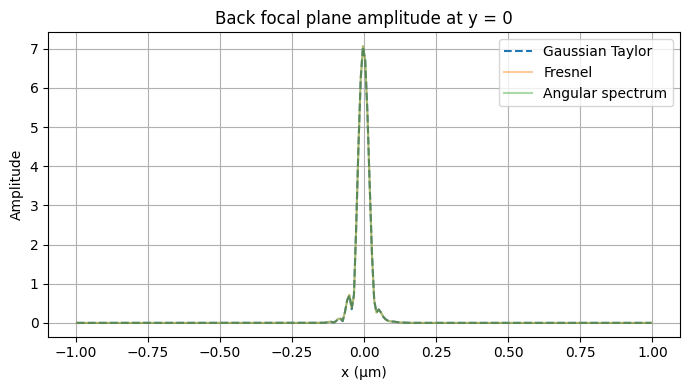

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
idx_y_center = Ny // 2

gaussian_amp_cross = np.abs(gaussian_field_at_back_focal_plane[idx_y_center, :])
fresnel_amp_cross = np.abs(fresnel_field_at_back_focal_plane[idx_y_center, :])
angular_amp_cross = np.abs(angular_field_at_back_focal_plane[idx_y_center, :])

ax.plot(x_coords * 1e6, gaussian_amp_cross, label="Gaussian Taylor", linestyle='--')
ax.plot(x_coords * 1e6, fresnel_amp_cross, label="Fresnel", alpha=0.4)
ax.plot(x_coords * 1e6, angular_amp_cross, label="Angular spectrum", alpha=0.4)
ax.set_xlabel("x (µm)")
ax.set_ylabel("Amplitude")
ax.set_title("Back focal plane amplitude at y = 0")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


## 3D Ray Diagram

Visualise the Gaussian rays leaving the lens and striking the back focal plane together with the resulting intensity map.


In [ ]:
try:
    import plotly.graph_objects as go
except ModuleNotFoundError:
    print("Plotly is optional; install temgym-core[examples] to render the 3D ray diagram.")
else:
    origin_um = float(np.asarray(rays_after_lens.z).mean()) * 1e6
    lens_xyz = np.column_stack([
        np.asarray(rays_after_lens.x) * 1e6,
        np.asarray(rays_after_lens.y) * 1e6,
        np.asarray(rays_after_lens.z) * 1e6 - origin_um,
    ])
    out_xyz = np.column_stack([
        np.asarray(rays_after_free_space.x) * 1e6,
        np.asarray(rays_after_free_space.y) * 1e6,
        np.asarray(rays_after_free_space.z) * 1e6 - origin_um,
    ])

    extent = np.asarray(input_grid.extent) * 1e6

    max_rays = 120
    # keep ray sampling as before
    ray_candidates = np.where(
        (out_xyz[:, 0] >= extent[0])
        & (out_xyz[:, 0] <= extent[1])
        & (out_xyz[:, 1] >= extent[2])
        & (out_xyz[:, 1] <= extent[3])
    )[0]
    if ray_candidates.size == 0:
        ray_candidates = np.arange(lens_xyz.shape[0])
    ray_step = max(1, ray_candidates.size // max_rays)
    ray_indices = ray_candidates[::ray_step]

    intensity = np.abs(gaussian_field_at_back_focal_plane) ** 2
    intensity_np = np.asarray(intensity, dtype=float)

    plane_stride = max(1, int(max(intensity_np.shape) / 256))

    x_coords_um = np.asarray(x_coords) * 1e6
    y_coords_um = np.asarray(y_coords) * 1e6
    x_sample = np.arange(0, x_coords_um.size, plane_stride)
    y_sample = np.arange(0, y_coords_um.size, plane_stride)

    Xc, Yc = np.meshgrid(x_coords_um[x_sample], y_coords_um[y_sample], indexing='xy')
    img_coarse = intensity_np[np.ix_(y_sample, x_sample)]

    upsample_to = 320
    nx = max(upsample_to, Xc.shape[1])
    ny = max(upsample_to, Xc.shape[0])

    tx = np.linspace(0, Xc.shape[1] - 1, nx)
    ty = np.linspace(0, Xc.shape[0] - 1, ny)
    ix = np.arange(Xc.shape[1])
    iy = np.arange(Xc.shape[0])
    tmp = np.stack([np.interp(tx, ix, row) for row in img_coarse], axis=0)
    img_hi = np.stack([np.interp(ty, iy, tmp[:, j]) for j in range(tmp.shape[1])], axis=1)

    X = np.linspace(Xc[0, 0], Xc[0, -1], img_hi.shape[1])
    Y = np.linspace(Yc[0, 0], Yc[-1, 0], img_hi.shape[0])
    X, Y = np.meshgrid(X, Y, indexing='xy')

    X_zoom = X
    Y_zoom = Y
    img_zoom = img_hi

    lo = float(np.nanpercentile(img_zoom, 2.0))      # higher floor than before
    hi = float(np.nanpercentile(img_zoom, 99.8))     # tighter ceiling to tame the core
    img_clipped = np.clip(img_zoom - lo, 0.0, hi - lo + 1e-18)
    img_norm = img_clipped / (hi - lo + 1e-18)

    alpha = 80.0  # 40–120 recommended; higher = stronger highlight compression
    img_disp = np.log1p(alpha * img_norm) / np.log1p(alpha)

    gamma = 1  # <1 lifts midtones slightly; set to 1.0 to disable
    img_disp = np.clip(img_disp, 0.0, 1.0) ** gamma


    z_plane_um = float(out_xyz[:, 2].mean())
    Z_plane = np.full_like(X_zoom, z_plane_um)

    surface = go.Surface(
        x=X_zoom,
        y=Y_zoom,
        z=Z_plane,
        surfacecolor=img_disp,
        colorscale="magma",
        reversescale=False,
        opacity=1.0,
        cmin=0.0,
        cmax=1.0,
        lighting=dict(ambient=1.0, diffuse=0.0, specular=0.0, roughness=1.0, fresnel=0.0),
        lightposition=dict(x=0, y=0, z=1),  # irrelevant when diffuse/specular=0
    )

    ray_x, ray_y, ray_z = [], [], []
    for idx in ray_indices:
        ray_x.extend([lens_xyz[idx, 0], out_xyz[idx, 0], None])
        ray_y.extend([lens_xyz[idx, 1], out_xyz[idx, 1], None])
        ray_z.extend([lens_xyz[idx, 2], out_xyz[idx, 2], None])

    rays = go.Scatter3d(
        x=ray_x,
        y=ray_y,
        z=ray_z,
        mode="lines",
        line=dict(color="limegreen", width=3.0),
        opacity=0.6,
        hoverinfo="skip",
    )

    z_min = min(lens_xyz[:, 2].min(), z_plane_um - 0.25 * abs(z_plane_um))
    z_max = z_plane_um * 1.05

    # zoom in more: show a smaller fraction of the full image around the center
    zoom_factor = 1  # fraction of full extent to display (smaller -> more zoom)

    x_min_full = float(X_zoom.min())
    x_max_full = float(X_zoom.max())
    y_min_full = float(Y_zoom.min())
    y_max_full = float(Y_zoom.max())

    x_center = 0.5 * (x_min_full + x_max_full)
    y_center = 0.5 * (y_min_full + y_max_full)

    half_x = 0.5 * (x_max_full - x_min_full) * zoom_factor
    half_y = 0.5 * (y_max_full - y_min_full) * zoom_factor

    x_range_zoom = [x_center - half_x, x_center + half_x]
    y_range_zoom = [y_center - half_y, y_center + half_y]

    fig = go.Figure(data=[surface, rays])
    fig.update_layout(
        scene=dict(
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            zaxis=dict(visible=False, autorange="reversed"),
            aspectratio=dict(x=1, y=1, z=0.25),
            camera=dict(eye=dict(x=1.2, y=1.1, z=0.9)),
            # zoomed ranges
            xaxis_range=[float(x_range_zoom[0]), float(x_range_zoom[1])],
            yaxis_range=[float(y_range_zoom[0]), float(y_range_zoom[1])],
            zaxis_range=[z_min, z_max],
        ),
        margin=dict(l=0, r=0, t=0, b=0),
        paper_bgcolor="rgba(0,0,0,0)",
    )
    fig.show()
